# Empirical distributions

Every exact distribution `phasegen` computes can also be *sampled*. {meth}`~phasegen.distributions.PhaseTypeDistribution.to_empirical` draws genealogies from the same phase-type generator and returns an empirical counterpart ({class}`~phasegen.distributions.EmpiricalPhaseTypeDistribution`) that exposes the same interface as the exact {class}`~phasegen.distributions.PhaseTypeDistribution`, only estimated by Monte Carlo rather than the exact matrix computation.

```{versionadded} 2.0
```

This serves two purposes. First, a fast, independent check that the exact results are right. Second, because the sampler is fully vectorised, a fallback for state spaces too large for the exact computation to remain tractable.

In [1]:
Sys.setenv(TQDM_DISABLE = "1")
setwd("~/PycharmProjects/PhaseGen/")
reticulate::use_condaenv("/Users/janek/miniforge3/envs/dev-phasegen", required = TRUE)

In [2]:
mpl <- reticulate::import("matplotlib")
mpl$use("Agg")
plt <- reticulate::import("matplotlib.pyplot")
plt$rcParams[["figure.figsize"]] <- c(4.4, 3.3)
options(repr.plot.width = 4.4, repr.plot.height = 3.3)

# render a phasegen plot object (calls its .plot()) inline
render <- function(obj) {
  p <- tempfile(fileext = ".png"); obj$plot(show = FALSE, file = p); IRdisplay::display_png(file = p)
}
# render an arbitrary matplotlib figure drawn by `draw`, which saves to the given path
render_fn <- function(draw) {
  p <- tempfile(fileext = ".png"); draw(p); IRdisplay::display_png(file = p)
}
# run a call and echo the phasegen log output it emits, so it is captured in the rendered cell
with_log <- function(expr) cat(reticulate::py_capture_output(expr))

In [3]:
library(phasegen)

pg <- load_phasegen()

## Sampling a spectrum

Take a two-population demography with a size change and asymmetric migration. {meth}`~phasegen.distributions.JointSFSDistribution.to_empirical` draws genealogies from this model and bins each one's branch lengths into the joint SFS; its `mean` is the sampled counterpart of the exact {meth}`~phasegen.distributions.Coalescent.jsfs`.

In [4]:
coal <- pg$Coalescent(
    n = pg$LineageConfig(list(pop_0 = 4, pop_1 = 4)),
    demography = pg$Demography(
        pop_sizes = list(
            pop_0 = reticulate::py_dict(list(0, 1), list(1, 0.3)),
            pop_1 = reticulate::py_dict(list(0), list(1.5))
        ),
        migration_rates = reticulate::py_dict(
            list(reticulate::tuple("pop_0", "pop_1"), reticulate::tuple("pop_1", "pop_0")),
            list(0.5, 0.2)
        )
    )
)

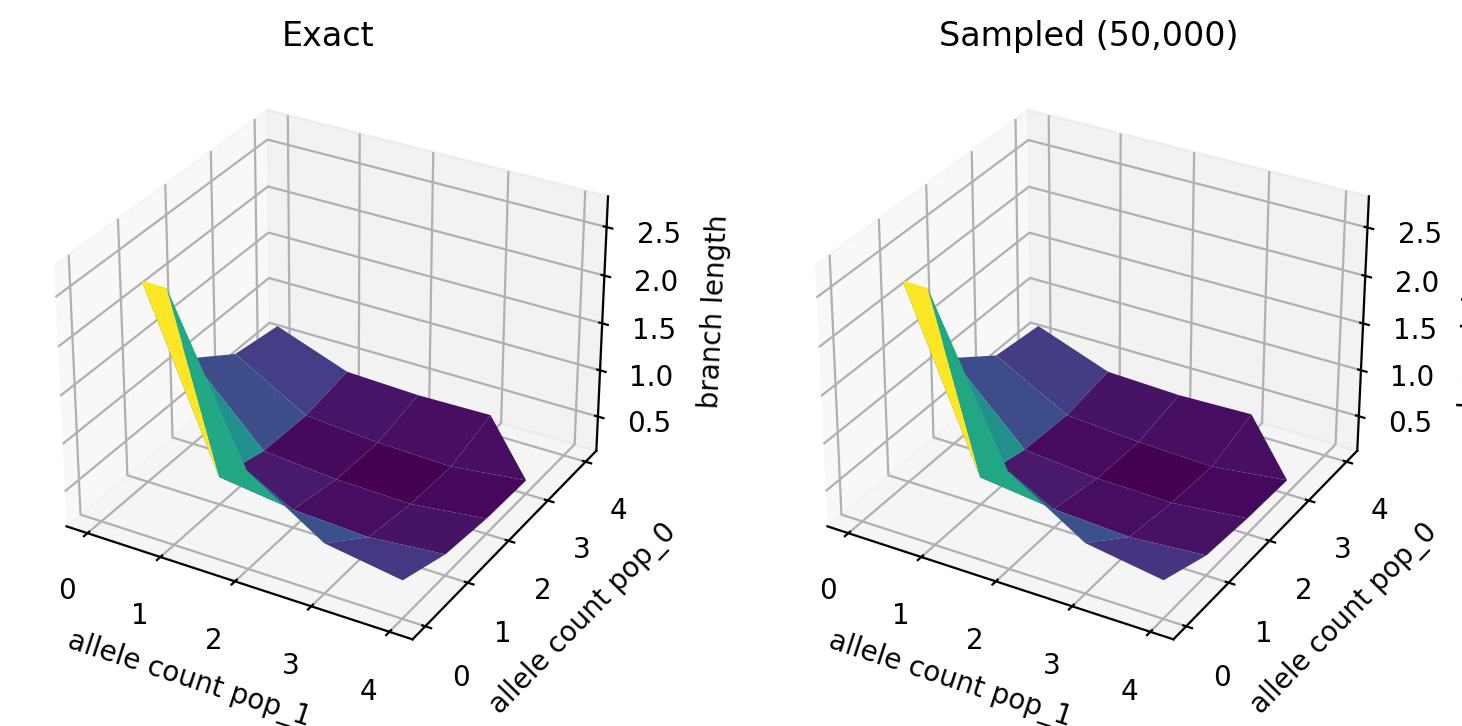

In [5]:
# the sampled mean joint SFS reproduces the exact surface from 50,000 genealogies
sampled <- coal$jsfs$to_empirical(50000L)

render_fn(function(f) {
    res <- plt$subplots(ncols = 2L, figsize = c(9, 4), subplot_kw = list(projection = "3d"))
    axs <- res[[2]]
    coal$jsfs$mean$plot_surface(ax = axs[[1]], show = FALSE, title = "Exact")
    sampled$mean$plot_surface(ax = axs[[2]], show = FALSE, title = "Sampled (50,000)")
    plt$savefig(f, dpi = 200, bbox_inches = "tight"); plt$close("all")
})

Because the empirical object exposes the *same* interface as the exact distribution, scalar summaries compare directly. A hundred thousand genealogies recover the exact tree height and total branch length to three digits.

In [6]:
th <- coal$tree_height$to_empirical(100000L)
tbl <- coal$total_branch_length$to_empirical(100000L)

cat(sprintf("%-22s%10s%10s\n", "", "exact", "sampled"))
cat(sprintf("%-22s%10.3f%10.3f\n", "tree height (mean)", coal$tree_height$mean, th$mean))
cat(sprintf("%-22s%10.3f%10.3f\n", "tree height (var)", coal$tree_height$var, th$var))
cat(sprintf("%-22s%10.3f%10.3f\n", "branch length (mean)", coal$total_branch_length$mean, tbl$mean))

                           exact   sampled


tree height (mean)         4.794     4.798


tree height (var)          8.442     8.449


branch length (mean)      14.033    14.033


## External ground truth

{meth}`~phasegen.distributions.Coalescent.to_msprime` returns an `msprime`-backed coalescent ({class}`~phasegen.distributions.MsprimeCoalescent`) with the same interface. Where `to_empirical` is `phasegen`'s own sampler, this is a fully independent implementation: an external ground truth rather than a self-consistency check, at the cost of the slower, non-vectorised `msprime` simulation. `phasegen` is extensively validated against msprime across a wide range of scenarios.

In [7]:
ms <- coal$to_msprime(num_replicates = 5000L, seed = 42L)

cat(sprintf("tree height mean   exact = %.3f   msprime = %.3f\n",
            coal$tree_height$mean, ms$tree_height$mean))

tree height mean   exact = 4.794   msprime = 4.749
